# PD Credit Scoring

This notebook is dedicated exclusively to the operational scoring layer built
on top of the final Probability of Default (PD) model.

The PD model is **not trained or tuned here**. The finalized model exported by
the model-development notebook is reloaded and used as a fixed input.

The scoring workflow is:

**Borrower Features → Predicted PD → Good-to-Bad Odds → Credit Score → Risk Grade → Risk Level**

The development and test datasets are loaded only to validate the score
distribution and the stability of the risk-grade framework. In a production
application, the same scoring logic can be applied to a new borrower after the
required feature-transformation pipeline has generated the model-ready inputs.


In [1]:
# =============================================================================
# Imports and Project Paths
# =============================================================================

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from joblib import load
from matplotlib.ticker import PercentFormatter


# =============================================================================
# Project Root
# =============================================================================

CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# =============================================================================
# Project Paths
# =============================================================================

PD_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "pd"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "pd"
)


# =============================================================================
# Project Configuration
# =============================================================================

from src.config import (
    BASE_SCORE,
    BASE_ODDS,
    PDO,
    RISK_COLORS,
)


# =============================================================================
# Scoring Utilities
# =============================================================================

from src.scoring import (
    FACTOR,
    OFFSET,
    build_scoring_output,
)
from src.visualization import (
    plot_risk_gauge,
)

In [2]:
# =============================================================================
# Load Final PD Model and Validation Data
# =============================================================================

FINAL_PD_MODEL_PATH = (
    MODEL_DIR
    / "final_pd_model.joblib"
)

if not FINAL_PD_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Final PD model not found: {FINAL_PD_MODEL_PATH}"
    )

final_pd_model = load(
    FINAL_PD_MODEL_PATH
)

X_train_encoded = pd.read_parquet(
    PD_DATA_DIR / "pd_X_train_encoded.parquet"
)

X_test_encoded = pd.read_parquet(
    PD_DATA_DIR / "pd_X_test_encoded.parquet"
)

y_train = (
    pd.read_parquet(
        PD_DATA_DIR / "pd_y_train.parquet"
    )
    .squeeze("columns")
)

y_test = (
    pd.read_parquet(
        PD_DATA_DIR / "pd_y_test.parquet"
    )
    .squeeze("columns")
)

assert X_train_encoded.columns.equals(
    X_test_encoded.columns
)

print("Final PD Model Loaded")
print("=" * 60)
print(f"Model : {final_pd_model.__class__.__name__}")
print(f"Path  : {FINAL_PD_MODEL_PATH}")
print("=" * 60)


Final PD Model Loaded
Model : HistGradientBoostingClassifier
Path  : C:\Users\htouy\OneDrive - HEC Montréal\Bureau\GitHub\risk-credit-scoring-new\models\pd\final_pd_model.joblib


## 1. Credit Score Construction

For each borrower, the final PD model produces an estimated Probability of
Default:

$$
PD_i = P(Y_i = 1 \mid X_i)
$$

The predicted PD is converted into good-to-bad odds:

$$
Odds_i = \frac{1 - PD_i}{PD_i}
$$

where higher odds indicate lower credit risk.

The odds are then mapped onto a credit-score scale using a logarithmic
transformation. Three parameters define the score scale:

- **Base Score:** the score assigned to a predefined reference level of odds;
- **Base Odds:** the good-to-bad odds associated with the base score;
- **PDO (Points to Double the Odds):** the number of score points gained when
  the good-to-bad odds double.

The scaling factor and offset are defined as:

$$
Factor = \frac{PDO}{\ln(2)}
$$

$$
Offset = BaseScore - Factor \times \ln(BaseOdds)
$$

The credit score is then calculated as:

$$
Score_i =
Offset +
Factor \times
\ln\left(\frac{1 - PD_i}{PD_i}\right)
$$

This transformation is strictly monotonic: lower predicted PDs generate higher
credit scores, while higher predicted PDs generate lower credit scores.

The scoring parameters and transformation logic are centralized in the project
configuration and scoring utilities to ensure consistent application across
portfolio analysis and future deployment.

In [3]:
# =============================================================================
# 1. Credit Score Construction
# =============================================================================

# Predicted Probability of Default
predicted_pd = final_pd_model.predict_proba(
    X_test_encoded
)[:, 1]


# Build borrower-level scoring output
credit_scoring_results = build_scoring_output(
    predicted_pd=predicted_pd,
    index=X_test_encoded.index,
)


# Retain observed outcome for out-of-sample validation
credit_scoring_results.insert(
    0,
    "Observed Default",
    y_test.to_numpy(),
)


# Score scaling summary
print("CREDIT SCORE SCALING")
print("=" * 50)
print(f"Base Score : {BASE_SCORE}")
print(f"Base Odds  : {BASE_ODDS}:1")
print(f"PDO        : {PDO}")
print(f"Factor     : {FACTOR:.4f}")
print(f"Offset     : {OFFSET:.4f}")

CREDIT SCORE SCALING
Base Score : 600
Base Odds  : 20:1
PDO        : 50
Factor     : 72.1348
Offset     : 383.9036


## 2. Score Distribution

The distribution of the generated credit scores is examined before defining
risk grades.

The analysis evaluates the empirical score range and verifies that the score
preserves the expected inverse relationship with the predicted Probability of
Default.

Descriptive statistics, the score distribution and the relationship between
PD and credit score are examined. No risk-grade thresholds are imposed at
this stage.

CREDIT SCORE DISTRIBUTION


,Credit Score
count,93257.00
mean,551.39
std,56.68
min,335.00
1%,436.00
5%,464.00
50%,548.00
95%,652.00
99%,686.00
max,739.00


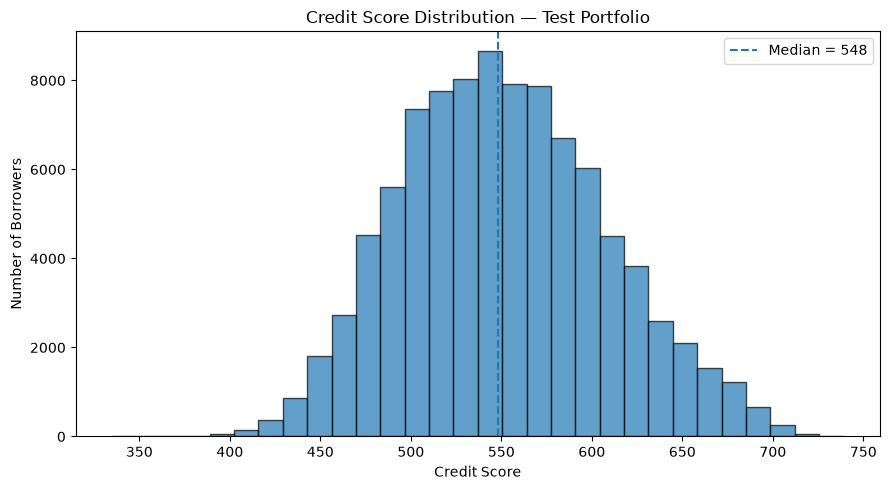

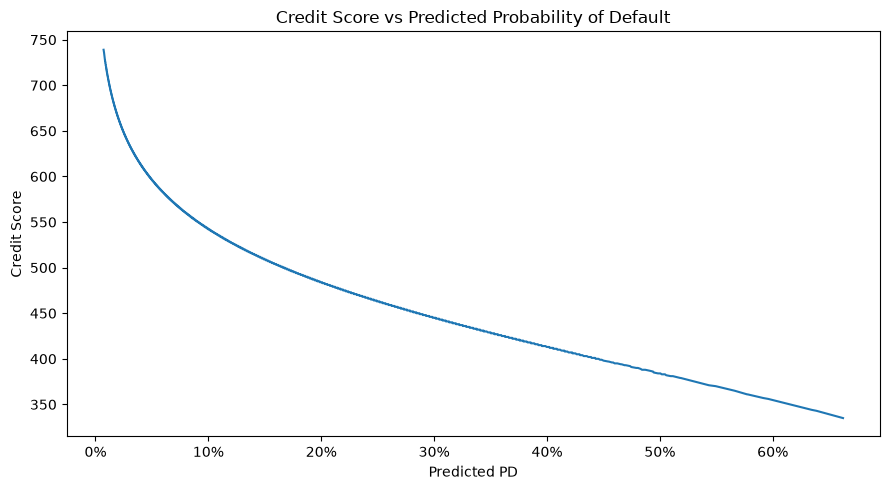

In [4]:
# =============================================================================
# 2. Score Distribution
# =============================================================================

# -----------------------------------------------------------------------------
# Descriptive statistics
# -----------------------------------------------------------------------------

score_summary = (
    credit_scoring_results["Credit Score"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.50,
            0.95,
            0.99,
        ]
    )
    .to_frame(
        name="Credit Score"
    )
)

print("CREDIT SCORE DISTRIBUTION")
print("=" * 60)

display(
    score_summary.round(2)
)


# -----------------------------------------------------------------------------
# Credit score distribution
# -----------------------------------------------------------------------------

median_score = (
    credit_scoring_results["Credit Score"]
    .median()
)

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    credit_scoring_results["Credit Score"],
    bins=30,
    edgecolor="black",
    alpha=0.7,
)

plt.axvline(
    median_score,
    linestyle="--",
    label=f"Median = {median_score:.0f}",
)

plt.xlabel("Credit Score")
plt.ylabel("Number of Borrowers")
plt.title("Credit Score Distribution — Test Portfolio")

plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# Relationship between PD and Credit Score
# -----------------------------------------------------------------------------

score_pd_relationship = (
    credit_scoring_results[
        [
            "Predicted PD",
            "Credit Score",
        ]
    ]
    .sort_values(
        "Predicted PD"
    )
)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    score_pd_relationship["Predicted PD"],
    score_pd_relationship["Credit Score"],
)

plt.xlabel("Predicted PD")
plt.ylabel("Credit Score")

plt.title(
    "Credit Score vs Predicted Probability of Default"
)

plt.gca().xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.tight_layout()
plt.show()

**Score Distribution Interpretation**

The test portfolio contains 93,257 borrowers, with a mean credit score of
551.39 and a median of 548. The standard deviation is 56.68.

Observed scores range from 335 to 739, while approximately 98% of borrowers
fall between 436 and 686.

The score distribution shows sufficient dispersion to differentiate borrowers
across the risk spectrum. No artificial clipping or additional rescaling is
therefore applied.

The expected inverse relationship between predicted PD and credit score is
preserved: borrowers with higher estimated probabilities of default receive
lower credit scores.

The resulting score distribution is retained without additional adjustment and
is used as the score representation of the underlying predicted default risk.


## 3. Risk Grade Construction

Credit scores are converted into ordered risk grades to provide an operational
and interpretable representation of borrower credit quality.

Because the credit score is a monotonic transformation of the predicted
Probability of Default (PD), risk grades are defined from PD thresholds rather
than arbitrary score intervals or fixed population proportions.

Five ordered risk grades are considered:

- **Grade A:** very low risk;
- **Grade B:** low risk;
- **Grade C:** moderate risk;
- **Grade D:** high risk;
- **Grade E:** very high risk.

Candidate PD boundaries are defined and evaluated on the development portfolio
by examining predicted PD, credit score, observed default rates and population
shares across the resulting risk segments.

A meaningful grading structure should exhibit a monotonic deterioration in
credit quality from Grade A to Grade E:

$$
PD_A < PD_B < PD_C < PD_D < PD_E
$$

and similarly:

$$
DR_A < DR_B < DR_C < DR_D < DR_E
$$

where $DR$ denotes the observed default rate.

The candidate boundaries are retained only if they provide clear risk
differentiation and are subsequently applied unchanged to the test portfolio
for out-of-sample validation.


In [5]:
# =============================================================================
# 3. Risk Grade Construction
# =============================================================================

# -----------------------------------------------------------------------------
# Development-set predicted PD
# -----------------------------------------------------------------------------

development_predicted_pd = (
    final_pd_model.predict_proba(
        X_train_encoded
    )[:, 1]
)


# -----------------------------------------------------------------------------
# Development scoring output
# -----------------------------------------------------------------------------

development_results = build_scoring_output(
    predicted_pd=development_predicted_pd,
    index=X_train_encoded.index,
)

development_results.insert(
    0,
    "Observed Default",
    y_train.to_numpy(),
)


# -----------------------------------------------------------------------------
# Risk-grade summary
# -----------------------------------------------------------------------------

risk_grade_summary = (
    development_results
    .groupby(
        "Risk Grade",
        observed=True,
    )
    .agg(
        Borrowers=("Predicted PD", "size"),
        Mean_PD=("Predicted PD", "mean"),
        Default_Rate=("Observed Default", "mean"),
        Min_Score=("Credit Score", "min"),
        Max_Score=("Credit Score", "max"),
    )
)

risk_grade_summary["Population_Share"] = (
    risk_grade_summary["Borrowers"]
    / risk_grade_summary["Borrowers"].sum()
)


display(
    risk_grade_summary.style.format({
        "Mean_PD": "{:.2%}",
        "Default_Rate": "{:.2%}",
        "Population_Share": "{:.2%}",
    })
)

,Borrowers,Mean_PD,Default_Rate,Min_Score,Max_Score,Population_Share
Risk Grade,,,,,,
A,31101,2.17%,1.46%,635,749,8.34%
B,75906,4.54%,3.71%,582,635,20.35%
C,93719,7.91%,7.40%,542,582,25.12%
D,129382,14.15%,14.19%,484,542,34.68%
E,42920,25.49%,28.44%,335,484,11.51%


**Risk Grade Interpretation**

The proposed PD-based grading structure produces a clear and monotonic
deterioration in credit quality from Grade A to Grade E.

Mean predicted PD increases from 2.17% for Grade A to 25.49% for Grade E,
while the observed default rate increases from 1.46% to 28.44%.

The grade populations are not artificially constrained to equal proportions,
indicating that the segmentation reflects the underlying risk structure of
the development portfolio rather than its empirical score distribution.

The resulting PD boundaries are therefore retained as candidate risk-grade
thresholds and will subsequently be evaluated on the test portfolio.


## 4. Out-of-Sample Risk Grade Validation

The candidate risk-grade thresholds defined on the development portfolio are
now applied unchanged to the test portfolio.

This out-of-sample validation assesses whether the proposed grading structure
preserves:

- increasing predicted PD from Grade A to Grade E;
- increasing observed default rates across grades;
- meaningful separation between risk segments;
- stable population allocation across the risk spectrum.

No grade thresholds are recalculated or adjusted using the test data.


In [6]:
# =============================================================================
# 4. Out-of-Sample Risk Grade Validation
# =============================================================================

# -----------------------------------------------------------------------------
# Test-set risk-grade summary
# -----------------------------------------------------------------------------

test_grade_summary = (
    credit_scoring_results
    .groupby(
        "Risk Grade",
        observed=True,
    )
    .agg(
        Borrowers=("Predicted PD", "size"),
        Mean_PD=("Predicted PD", "mean"),
        Default_Rate=("Observed Default", "mean"),
        Min_Score=("Credit Score", "min"),
        Max_Score=("Credit Score", "max"),
    )
)

test_grade_summary["Population_Share"] = (
    test_grade_summary["Borrowers"]
    / test_grade_summary["Borrowers"].sum()
)


display(
    test_grade_summary.style.format({
        "Mean_PD": "{:.2%}",
        "Default_Rate": "{:.2%}",
        "Population_Share": "{:.2%}",
    })
)

,Borrowers,Mean_PD,Default_Rate,Min_Score,Max_Score,Population_Share
Risk Grade,,,,,,
A,7726,2.17%,1.77%,635,739,8.28%
B,19170,4.54%,4.67%,582,635,20.56%
C,23419,7.91%,7.72%,542,582,25.11%
D,32250,14.15%,14.18%,484,542,34.58%
E,10692,25.49%,26.01%,335,484,11.47%


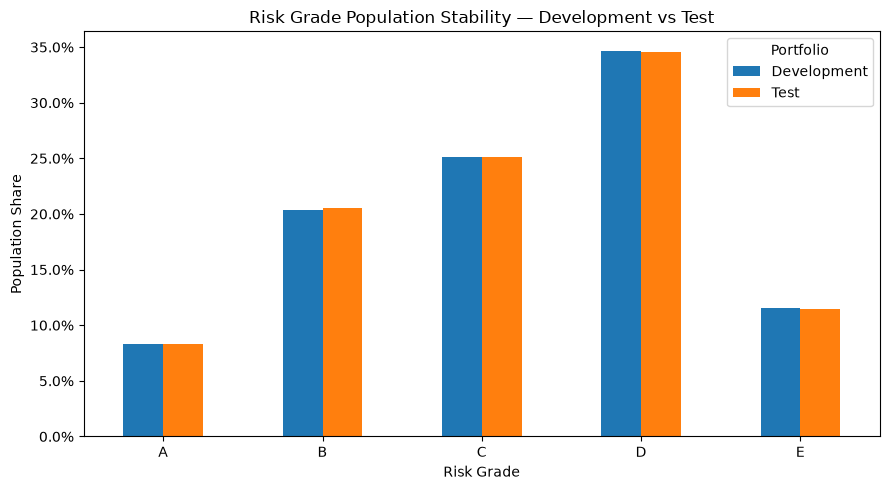

In [7]:
# -----------------------------------------------------------------------------
# Development vs test grade stability
# -----------------------------------------------------------------------------

grade_stability = pd.DataFrame({
    "Development": risk_grade_summary["Population_Share"],
    "Test": test_grade_summary["Population_Share"],
})

ax = grade_stability.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_xlabel("Risk Grade")
ax.set_ylabel("Population Share")
ax.set_title(
    "Risk Grade Population Stability — Development vs Test"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.xticks(rotation=0)

plt.legend(
    title="Portfolio"
)

plt.tight_layout()
plt.show()

**Out-of-Sample Validation**

The proposed risk-grade structure remains strongly monotonic on the test
portfolio. Observed default rates increase consistently from 1.77% for
Grade A to 26.01% for Grade E.

Predicted PD and observed default rates are also closely aligned across the
five grades, supporting the calibration and interpretability of the proposed
risk segmentation.

Population shares remain highly stable between the development and test
portfolios, providing additional evidence that the grading structure
generalizes well out of sample.

The PD thresholds of 3%, 6%, 10% and 20% are therefore retained as the final
risk-grade boundaries.


## 5. Final Scoring Output and Individual Borrower Examples

The final scoring framework combines four complementary representations of
borrower credit risk:

- **Predicted PD:** estimated probability of default;
- **Credit Score:** scaled representation of predicted PD;
- **Risk Grade:** operational category derived from the validated PD thresholds;
- **Risk Level:** business interpretation of the assigned risk grade.

<div align="center">

| Risk Grade | Risk Level | PD Range | Indicative Credit Score Range |
|:----------:|:-----------|:--------:|:-----------------------------:|
| **A** | Very Low Risk | PD ≤ 3% | **Score ≥ 635** |
| **B** | Low Risk | 3% < PD ≤ 6% | **582–635** |
| **C** | Moderate Risk | 6% < PD ≤ 10% | **542–582** |
| **D** | High Risk | 10% < PD ≤ 20% | **484–542** |
| **E** | Very High Risk | PD > 20% | **Score ≤ 484** |

</div>

> **Note:** Risk grades are assigned from predicted PD. Credit-score ranges
> are indicative because integer rounding may create overlap at grade
> boundaries.

The complete scoring chain is:

$$
X
\rightarrow
PD
\rightarrow
Credit\ Score
\rightarrow
Risk\ Grade
\rightarrow
Risk\ Level
$$

The validated PD thresholds remain fixed and can therefore be applied
consistently to any borrower scored by the final PD model.

To illustrate the complete scoring process, the first ten borrowers from the
final scoring output are presented and visualized using the same fixed scoring
and grading framework.


In [8]:
# =============================================================================
# 5. Final Scoring Output
# =============================================================================

final_scoring_output = (
    credit_scoring_results[
        [
            "Predicted PD",
            "Credit Score",
            "Risk Grade",
            "Risk Level",
        ]
    ]
    .copy()
)


# -----------------------------------------------------------------------------
# Individual borrower examples
# -----------------------------------------------------------------------------

sample_results = (
    final_scoring_output
    .head(10)
)


def highlight_risk(value):
    color = RISK_COLORS.get(
        str(value),
        "",
    )

    return (
        f"background-color: {color}; "
        f"font-weight: bold;"
    )


display(
    sample_results
    .style
    .format({
        "Predicted PD": "{:.2%}",
        "Credit Score": "{:.0f}",
    })
    .map(
        highlight_risk,
        subset=["Risk Grade"],
    )
)

,Predicted PD,Credit Score,Risk Grade,Risk Level
159089,23.30%,470,E,Very High Risk
204026,11.78%,529,D,High Risk
446918,10.30%,540,D,High Risk
309480,1.32%,695,A,Very Low Risk
427185,18.05%,493,D,High Risk
151984,13.62%,517,D,High Risk
128684,10.59%,538,D,High Risk
293471,2.91%,637,A,Very Low Risk
247882,11.44%,532,D,High Risk
366005,6.74%,573,C,Moderate Risk


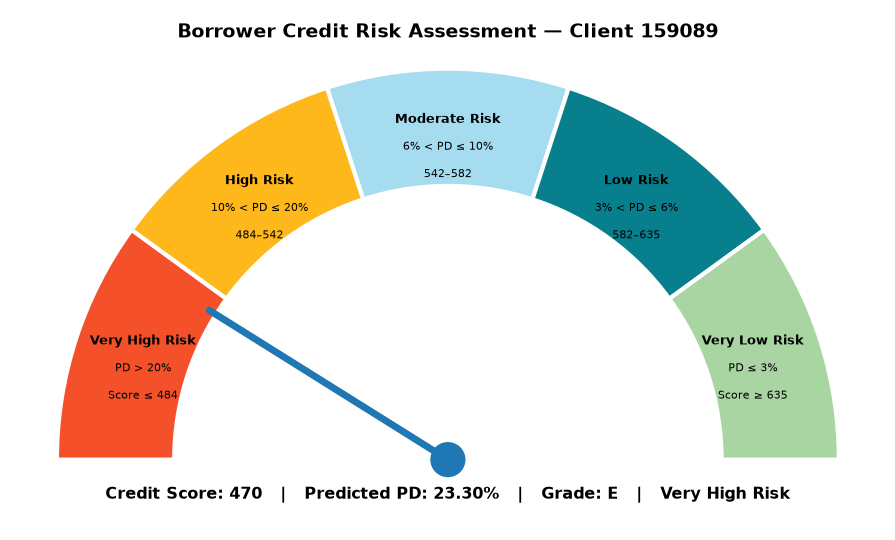

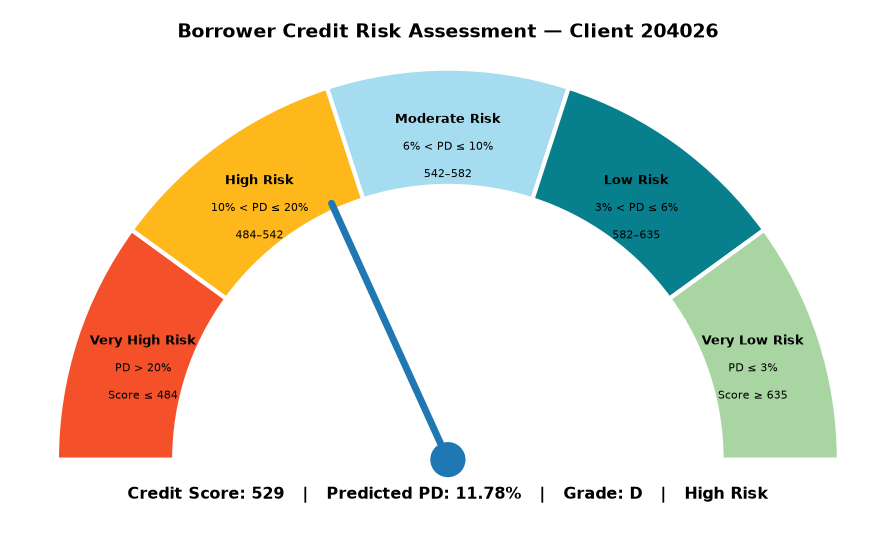

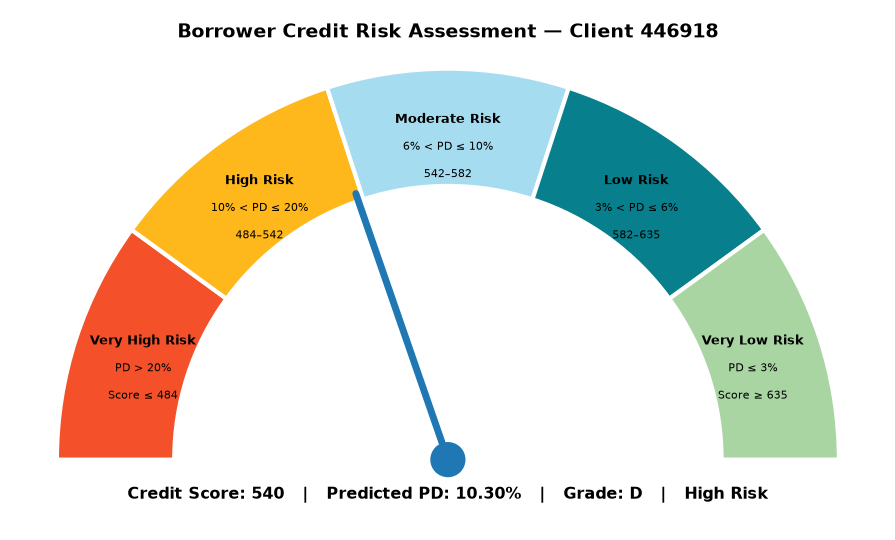

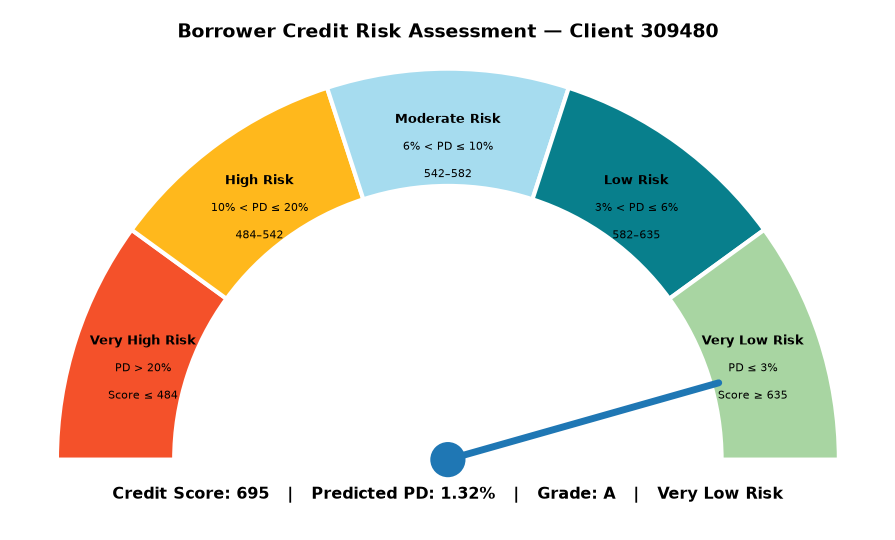

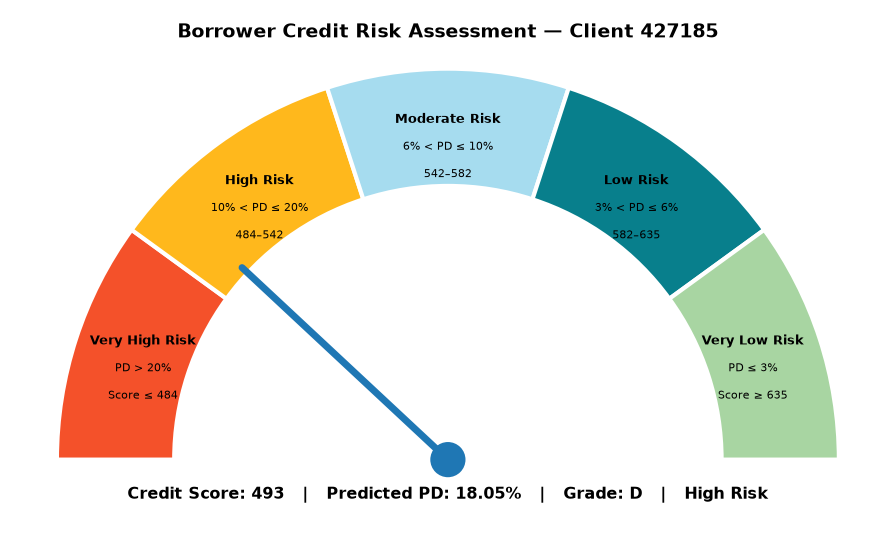

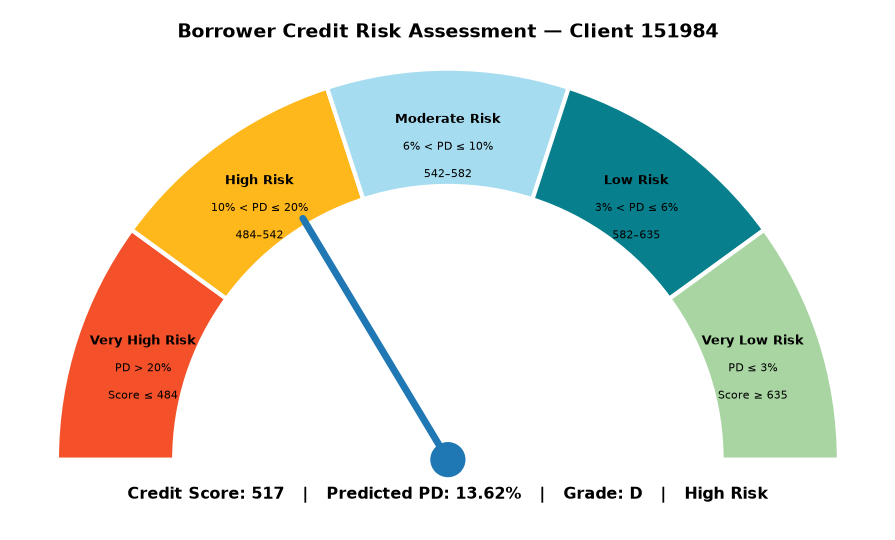

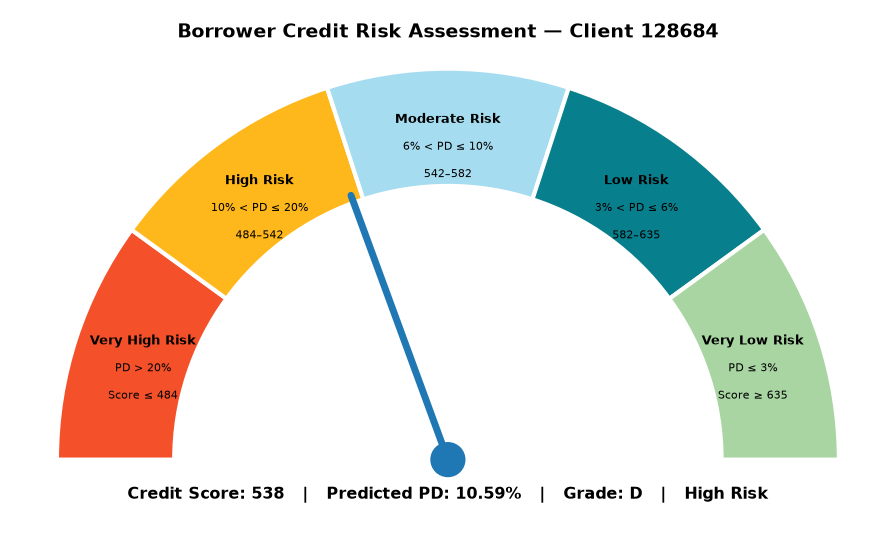

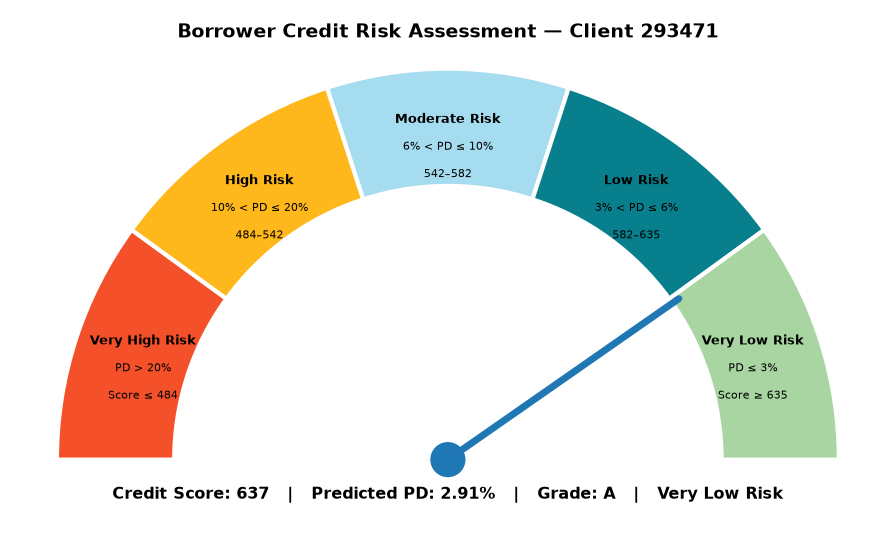

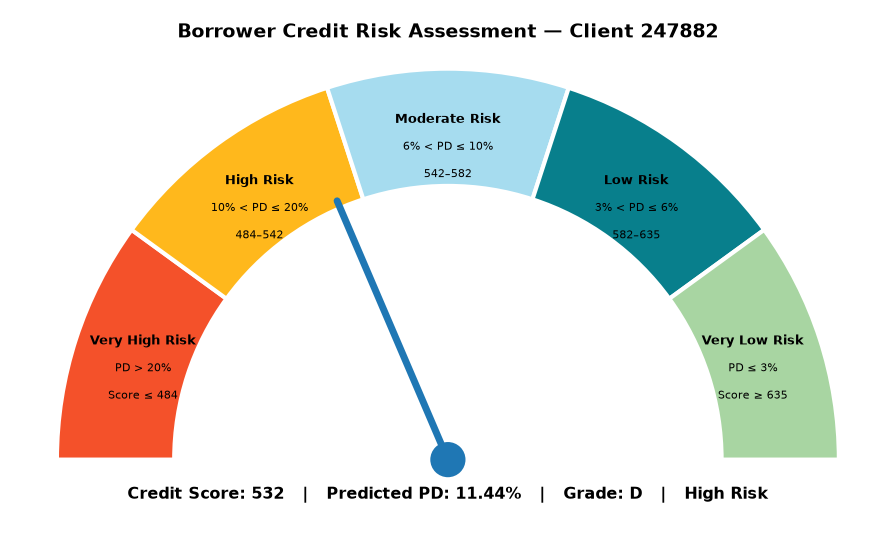

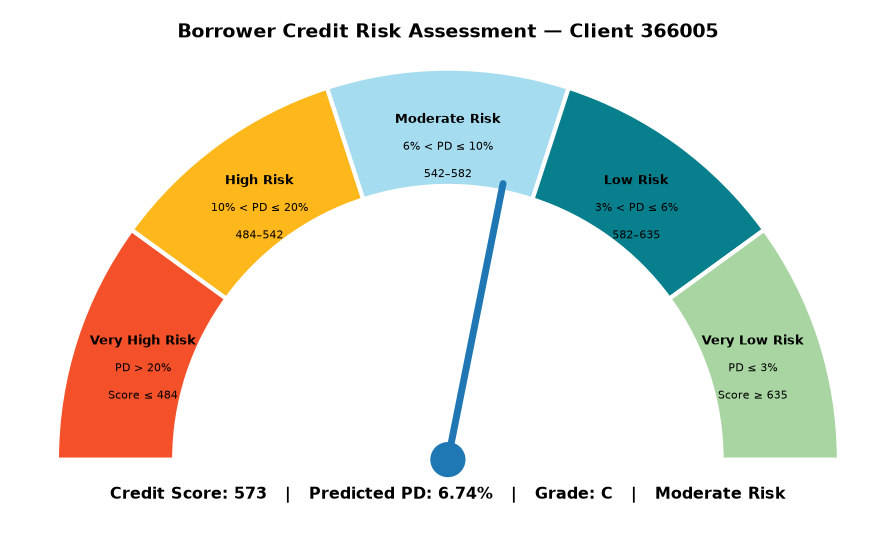

In [9]:
# =============================================================================
# Risk Gauges for the 10 Borrowers
# =============================================================================

for borrower_id, client in sample_results.iterrows():

    plot_risk_gauge(
        pd_value=float(client["Predicted PD"]),
        score=int(client["Credit Score"]),
        grade=str(client["Risk Grade"]),
        risk_level=str(client["Risk Level"]),
        borrower_id=borrower_id,
    )


# References

- Thomas, L. C. (2009). *Consumer Credit Models: Pricing, Profit and
  Portfolios*. Oxford University Press.  
  DOI: https://doi.org/10.1093/acprof:oso/9780199232130.001.1  
  Access: https://academic.oup.com/book/2180

- Siddiqi, N. (2012). *Credit Risk Scorecards: Developing and Implementing
  Intelligent Credit Scoring*. Wiley.  
  DOI: https://doi.org/10.1002/9781119201731  
  Access: https://onlinelibrary.wiley.com/doi/book/10.1002/9781119201731

- Anderson, R. A. (2021). *Credit Intelligence & Modelling: Many Paths
  through the Forest of Credit Rating and Scoring*. Oxford University Press.  
  DOI: https://doi.org/10.1093/oso/9780192844194.001.0001  
  Access: https://academic.oup.com/book/38955

- Baesens, B., Rösch, D., & Scheule, H. (2016). *Credit Risk Analytics:
  Measurement Techniques, Applications, and Examples in SAS*. Wiley.  
  DOI: https://doi.org/10.1002/9781119449560  
  Access: https://onlinelibrary.wiley.com/doi/book/10.1002/9781119449560

- Hand, D. J., & Henley, W. E. (1997). Statistical Classification Methods
  in Consumer Credit Scoring: A Review. *Journal of the Royal Statistical
  Society: Series A*, 160(3), 523–541.  
  DOI: https://doi.org/10.1111/j.1467-985X.1997.00078.x

- SAS Institute Inc. *Developing Credit Scorecards Using Credit Scoring
  for SAS Enterprise Miner — Scorecard Scaling and Points to Double Odds*.  
  Access: SAS Enterprise Miner Documentation.

- Basel Committee on Banking Supervision. *Basel Framework — Internal
  Ratings-Based Approach: Risk Components*.  
  Access: https://www.bis.org/basel_framework/